# Analisis Dataset & Justifikasi Penyusunan Query Uji
**Tujuan notebook:** mendokumentasikan secara transparan dari mana distribusi kategori
(`categoryId`) dan pasangan *query → ground truth* (`QUERY_GROUND_TRUTH`) pada notebook
utama (`skripsi.ipynb`) berasal, serta metode apa yang dipakai untuk menyusunnya.

Notebook ini **tidak melakukan retrieval atau evaluasi** — perannya murni sebagai bukti
metodologis bahwa query uji dan pseudo ground truth disusun berdasarkan analisis data
yang sistematis, bukan ditentukan secara sembarangan oleh peneliti.

Alur notebook:
1. Load & preprocessing dataset (identik dengan notebook utama)
2. Analisis distribusi dokumen per kategori (`categoryId`)
3. Analisis frekuensi kata/istilah dominan per kategori
4. Contoh dokumen representatif per kategori
5. Derivasi query uji dari hasil analisis, dibandingkan dengan `QUERY_GROUND_TRUTH` aktual


## 1. Instalasi Library

In [9]:
# Install library yang dibutuhkan (khusus Kaggle environment)
!pip install -q openpyxl


## 2. Import Library

In [10]:
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_colwidth', 80)
print('✅ Library siap')


✅ Library siap


## 3. Load Dataset

In [11]:
# ── Sesuaikan path dengan lokasi file di Kaggle (sama seperti notebook utama) ──
FILE_PATH = '/kaggle/input/datasets/muhammadhaekal74/dataset-arsip/dataset_arsip.xlsx'

df = pd.read_excel(FILE_PATH)

print(f'✅ Dataset berhasil dimuat')
print(f'   Jumlah baris   : {len(df):,}')
print(f'   Jumlah kolom   : {len(df.columns)}')
print(f'   Kolom tersedia : {df.columns.tolist()}')
print()
display(df[['title', 'description', 'keywords', 'categoryId']].head(3))


✅ Dataset berhasil dimuat
   Jumlah baris   : 784
   Jumlah kolom   : 18
   Kolom tersedia : ['id', 'uuid', 'title', 'document_number', 'year', 'description', 'file_path', 'file_name', 'mime_type', 'file_size_kb', 'created_at', 'updated_at', 'uploaderId', 'categoryId', 'access_level', 'unitKerjaId', 'keywords', 'suratId']



,title,description,keywords,categoryId
0,Pengangkatan tim Perumus Visi dan Misi Universitas Darussalam Gontor,Dokumen ini berisi tentang amanat Rektor perihal pengangkatan nama - nama te...,"SK, Rektor, pengangkatan, tim perumus, visi dan misi",3
1,Visi dan Misi Universitas Darussalam Gontor,Dokumen ini berisi tentang Visi dan Misi Universitas Darussalam Gontor sekal...,"SK, Keputusan, Rektor, Visi dan Misi, UNIDA",3
2,Penetapan Struktur Fungsionaris Centre For Islamic Economic Studies (CIES),Dokumen ini berisi tentang nama - nama yang di tetapkan oleh Rektor dalam st...,"SK, Rektor, Fungsionaris, CIES, UNIDA",3


## 4. Pra Pemrosesan Data\n\nSama persis dengan notebook utama (`skripsi.ipynb`), agar analisis di sini konsisten dengan teks yang benar-benar dipakai sistem untuk retrieval.

In [12]:
def clean_text(text: str) -> str:
    # Bersihkan teks: lowercase, hapus karakter khusus, normalisasi spasi.
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def build_combined_text(row: pd.Series) -> str:
    # Gabungkan kolom title + description + keywords menjadi satu teks.
    parts = [
        clean_text(str(row.get('title', ''))),
        clean_text(str(row.get('description', ''))),
        clean_text(str(row.get('keywords', '')))
    ]
    return ' '.join(p for p in parts if p)


df['combined_text'] = df.apply(build_combined_text, axis=1)
df = df[df['combined_text'].str.strip() != ''].reset_index(drop=True)

print('✅ Preprocessing selesai')
print(f'   Dokumen valid  : {len(df):,}')


✅ Preprocessing selesai
   Dokumen valid  : 784


## 5. Distribusi Dokumen per Kategori (`categoryId`)

Bagian ini menghasilkan angka-angka yang selama ini muncul sebagai komentar referensi
di notebook utama (mis. "categoryId 3 → SK & Kebijakan Universitas (324 dok)") —
**dihitung langsung dari data**, bukan angka yang ditulis manual tanpa sumber.

   DISTRIBUSI DOKUMEN PER KATEGORI
  categoryId 1 → Foto & Dokumentasi (77 dok)
  categoryId 3 → SK & Kebijakan Universitas (324 dok)
  categoryId 4 → Surat Menyurat & Kunjungan (19 dok)
  categoryId 5 → Akreditasi & Sertifikasi (57 dok)
  categoryId 6 → Panduan & Pedoman Akademik (75 dok)
  categoryId 7 → Laporan Kegiatan (25 dok)
  categoryId 8 → SOP & Anggaran (207 dok)
  Total: 784 dokumen


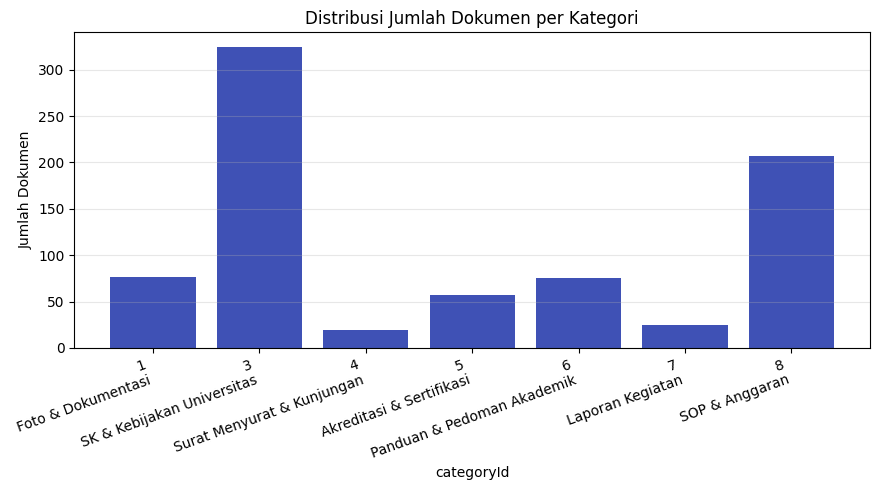

In [13]:
# Mapping categoryId ke nama kategori
# (nama kategori ditentukan berdasarkan pembacaan manual terhadap sampel judul
#  dan deskripsi dokumen pada tiap categoryId — lihat Bagian 7 untuk buktinya)
CATEGORY_NAMES = {
    1: 'Foto & Dokumentasi',
    3: 'SK & Kebijakan Universitas',
    4: 'Surat Menyurat & Kunjungan',
    5: 'Akreditasi & Sertifikasi',
    6: 'Panduan & Pedoman Akademik',
    7: 'Laporan Kegiatan',
    8: 'SOP & Anggaran',
}

category_counts = df['categoryId'].value_counts().sort_index()

print('=' * 55)
print('   DISTRIBUSI DOKUMEN PER KATEGORI')
print('=' * 55)
for cat_id, count in category_counts.items():
    cat_name = CATEGORY_NAMES.get(cat_id, f'Kategori {cat_id}')
    print(f'  categoryId {cat_id} → {cat_name} ({count} dok)')
print('=' * 55)
print(f'  Total: {category_counts.sum()} dokumen')

# ── Visualisasi ────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
labels = [f'{cid}\n{CATEGORY_NAMES.get(cid, "")}' for cid in category_counts.index]
plt.bar(labels, category_counts.values, color='#3F51B5')
plt.title('Distribusi Jumlah Dokumen per Kategori')
plt.xlabel('categoryId')
plt.ylabel('Jumlah Dokumen')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Analisis Frekuensi Istilah Dominan per Kategori

Untuk menyusun query uji yang benar-benar mencerminkan isi tiap kategori (bukan
menebak-nebak), dilakukan analisis kata/istilah yang paling sering muncul pada
`combined_text` di masing-masing kategori. Kata umum non-informatif (*stopwords*
Bahasa Indonesia) dibuang terlebih dahulu agar istilah yang muncul benar-benar
mencerminkan topik kategori tersebut, bukan kata sambung yang muncul di semua
kategori.

In [14]:
# Daftar stopword Bahasa Indonesia (kata umum non-informatif)
INDONESIAN_STOPWORDS = {
    'yang', 'dan', 'di', 'ke', 'dari', 'untuk', 'pada', 'dengan', 'ini', 'itu',
    'atau', 'adalah', 'akan', 'juga', 'dalam', 'oleh', 'sebagai', 'tersebut',
    'dapat', 'tidak', 'ada', 'tahun', 'nomor', 'no', 'tentang', 'serta', 'para',
    'telah', 'antara', 'terkait', 'seperti', 'guna', 'agar', 'bagi', 'kepada',
    'setiap', 'sebuah', 'suatu', 'lain', 'maupun', 'yaitu', 'yakni', 'bahwa',
}


def top_terms_per_category(dataframe, category_col='categoryId', text_col='combined_text',
                            top_n=15, min_word_len=3):
    # Hitung N kata paling sering muncul per kategori (setelah stopword removal).
    results = {}
    for cat_id, group in dataframe.groupby(category_col):
        counter = Counter()
        for text in group[text_col]:
            words = [w for w in text.split()
                     if len(w) >= min_word_len and w not in INDONESIAN_STOPWORDS]
            counter.update(words)
        results[cat_id] = counter.most_common(top_n)
    return results


term_frequencies = top_terms_per_category(df)

print('=' * 70)
print('   ISTILAH PALING SERING MUNCUL PER KATEGORI (Top 15)')
print('=' * 70)
for cat_id, terms in term_frequencies.items():
    cat_name = CATEGORY_NAMES.get(cat_id, f'Kategori {cat_id}')
    term_str = ', '.join(f'{w} ({c})' for w, c in terms)
    print(f'\n[{cat_id}] {cat_name}:')
    print(f'  {term_str}')


   ISTILAH PALING SERING MUNCUL PER KATEGORI (Top 15)

[1] Foto & Dokumentasi:
  foto (155), rapat (73), gontor (66), kegiatan (61), rektor (54), dokumentasi (51), unida (47), darussalam (46), lp2ip (43), pondok (39), universitas (38), obe (35), penyusunan (28), tanggal (27), modern (26)

[3] SK & Kebijakan Universitas:
  penelitian (449), gontor (368), darussalam (280), universitas (279), kontrak (248), mahasiswa (233), dokumen (229), berisi (223), 2025 (211), hibah (206), rektor (196), dosen (158), fakultas (158), dekan (157), relasi (152)

[4] Surat Menyurat & Kunjungan:
  permohonan (48), magang (42), kerja (29), pkl (28), surat (23), gontor (19), mahasiswa (19), darussalam (17), fakultas (16), 2025 (16), universitas (15), arsip (15), program (15), studi (15), pengajuan (15)

[5] Akreditasi & Sertifikasi:
  akreditasi (171), sertifikat (169), studi (69), program (69), darussalam (65), berlaku (57), sampai (56), gontor (55), dokumen (55), berisi (55), islam (53), peringkat (48), uni

## 7. Contoh Dokumen Representatif per Kategori

Selain analisis frekuensi kata, judul dokumen aktual per kategori ditampilkan sebagai
bukti tambahan — sumber langsung yang dipakai untuk memvalidasi bahwa nama kategori
pada `CATEGORY_NAMES` (Bagian 5) sesuai dengan isi dokumen sesungguhnya, bukan sekadar
asumsi dari nama kolom.

In [15]:
SAMPLES_PER_CATEGORY = 5

for cat_id in sorted(df['categoryId'].unique()):
    cat_name = CATEGORY_NAMES.get(cat_id, f'Kategori {cat_id}')
    sample_titles = df[df['categoryId'] == cat_id]['title'].sample(
        n=min(SAMPLES_PER_CATEGORY, (df['categoryId'] == cat_id).sum()),
        random_state=42
    ).tolist()

    print(f'[{cat_id}] {cat_name}')
    for t in sample_titles:
        print(f'   - {t}')
    print()


[1] Foto & Dokumentasi
   - Foto KH Imam Badri
   - Pelaksanaan Review Kurikulum Program Studi Tadris Bahasa Inggris Bersama Dr. Ana Maghfiroh, M.Pd. 
   - Foto Pimpinan Pondok Drs. K.H. M. Akrim Mariyat, Dipl.A.Ed
   - Foto KH Ahmad Sahal
   - Rapat Pleno Penyusunan Template RPKPS Berbasis OBE

[3] SK & Kebijakan Universitas
   - Pengangkatan Dosen Pembimbing Akademik Prodi Hubungan Internasional
   - Pemberlakuan Buku Pedoman Penelitian dan PKM 
   - Penunjukan Dosen Pembimbing Akademik Prodi Teknologi Industri Pertanian
   - Pengangkatan Panitia Pembekalan Wisudawan/Wati ke 40
   - Pengangkatan Pengurus Dewan Mahasiswa 

[4] Surat Menyurat & Kunjungan
   - Penerimaan Permohonan Kunjungan Fakultas Tarbiyah UNIDA Gontor
   - Permohonan magang/PKL 
   - Permohonan magang/PKL 
   - Penerimaan Kunjungan BKUI ke Balai Bahasa Jawa Timur
   - Permohonan magang/PKL 

[5] Akreditasi & Sertifikasi
   - Sertifikat Akreditasi Institut Studi Islam Darussalam Gontor ISID
   - Sertifikat Akreditasi

## 8. Derivasi Query Uji dari Hasil Analisis

Bagian ini menunjukkan bagaimana istilah-istilah dominan pada Bagian 6 dan contoh
dokumen pada Bagian 7 **secara langsung menjadi dasar** penyusunan query uji dan
pasangan ground truth (`QUERY_GROUND_TRUTH`) yang dipakai pada evaluasi di notebook
utama. Setiap query dibangun dari kombinasi istilah dominan kategori tersebut,
sehingga query merepresentasikan kosakata nyata yang muncul pada dokumen kategori
itu — bukan kalimat yang dibuat sembarangan tanpa dasar dari data.

In [16]:
# ── Query uji aktual yang dipakai pada notebook utama (skripsi.ipynb) ──
QUERY_GROUND_TRUTH = {
    'pengangkatan rektor universitas'        : 3,  # SK & Kebijakan Universitas
    'surat keputusan fakultas'               : 3,  # SK & Kebijakan Universitas
    'surat pernyataan'                       : 3,  # SK & Kebijakan Universitas
    'sertifikasi akreditasi program studi'   : 5,  # Akreditasi & Sertifikasi
    'anggaran kegiatan'                      : 8,  # SOP & Anggaran
    'standar operasional prosedur instansi'  : 8,  # SOP & Anggaran
    'laporan kegiatan workshop sosialisasi'  : 7,  # Laporan Kegiatan
}

print('=' * 78)
print('   VALIDASI: APAKAH ISTILAH DALAM QUERY MUNCUL DI TOP-TERMS KATEGORINYA?')
print('=' * 78)

for query, cat_id in QUERY_GROUND_TRUTH.items():
    cat_name = CATEGORY_NAMES.get(cat_id, f'Kategori {cat_id}')
    top_words_set = {w for w, _ in term_frequencies.get(cat_id, [])}

    query_words = [w for w in clean_text(query).split() if len(w) >= 3]
    matched = [w for w in query_words if w in top_words_set]
    match_ratio = len(matched) / len(query_words) if query_words else 0

    status = '✅' if matched else '⚠️'
    print(f'\n{status} Query: "{query}"  →  ground truth: [{cat_id}] {cat_name}')
    print(f'   Kata dalam query yang cocok dengan top-terms kategori: {matched if matched else "(tidak ada match langsung)"}')
    print(f'   Rasio kecocokan: {match_ratio:.0%}')

print()
print('Catatan: query yang tidak menunjukkan match langsung ke top-terms tetap dapat')
print('dijustifikasi lewat pembacaan manual contoh dokumen (Bagian 7), karena top-terms')
print('hanya menangkap frekuensi kata literal, bukan kedekatan makna/semantik.')


   VALIDASI: APAKAH ISTILAH DALAM QUERY MUNCUL DI TOP-TERMS KATEGORINYA?

✅ Query: "pengangkatan rektor universitas"  →  ground truth: [3] SK & Kebijakan Universitas
   Kata dalam query yang cocok dengan top-terms kategori: ['rektor', 'universitas']
   Rasio kecocokan: 67%

✅ Query: "surat keputusan fakultas"  →  ground truth: [3] SK & Kebijakan Universitas
   Kata dalam query yang cocok dengan top-terms kategori: ['fakultas']
   Rasio kecocokan: 33%

⚠️ Query: "surat pernyataan"  →  ground truth: [3] SK & Kebijakan Universitas
   Kata dalam query yang cocok dengan top-terms kategori: (tidak ada match langsung)
   Rasio kecocokan: 0%

✅ Query: "sertifikasi akreditasi program studi"  →  ground truth: [5] Akreditasi & Sertifikasi
   Kata dalam query yang cocok dengan top-terms kategori: ['akreditasi', 'program', 'studi']
   Rasio kecocokan: 75%

✅ Query: "anggaran kegiatan"  →  ground truth: [8] SOP & Anggaran
   Kata dalam query yang cocok dengan top-terms kategori: ['anggaran']
   Rasi

## 9. Catatan Metodologis

**Ringkasan proses penyusunan query uji dan ground truth:**

1. Dataset dianalisis untuk mengetahui distribusi dokumen per `categoryId` (Bagian 5).
2. Nama kategori (`CATEGORY_NAMES`) ditentukan melalui pembacaan manual terhadap
   istilah dominan (Bagian 6) dan sampel judul dokumen (Bagian 7) pada tiap kategori.
3. Query uji disusun dengan merujuk pada kosakata yang benar-benar muncul di dokumen
   kategori terkait, kemudian ditetapkan `categoryId`-nya sebagai *pseudo ground truth*
   — proses ini dilakukan **sebelum** query dijalankan pada sistem retrieval, sehingga
   independen dari hasil pencarian (menghindari bias konfirmasi).

**Keterbatasan yang perlu diakui:**

- Ground truth bersifat *level-kategori* (semua dokumen dalam satu kategori dianggap
  relevan), bukan anotasi relevansi *level-dokumen* oleh manusia — pendekatan proxy
  ini dipakai karena keterbatasan waktu/sumber daya untuk anotasi manual pada skala
  dataset ini.
- Jumlah query uji terbatas (7 query) dan disusun oleh peneliti sendiri, sehingga
  berpotensi bias terhadap query yang "mudah cocok" dengan kategorinya.
- Analisis frekuensi kata (Bagian 6) menangkap kecocokan literal/leksikal, bukan
  kedekatan semantik — sehingga tidak semua query uji harus menunjukkan *match*
  langsung terhadap top-terms untuk tetap valid secara makna.
